# LLM Market Analytics Examples

This notebook demonstrates how to use the LLM-based market forecaster for analyzing and predicting market movements.

## Load and Prepare Sample Data

Let's create some sample market data for demonstration purposes.

In [50]:
from finpie.datasource.service import DataService

#This notebook demonstrates how to use the LLM-based market forecaster for analyzing and predicting market movements.
# Define parameters for data fetching
symbol = "BOVA11"  # Change to your desired symbol
start_date = "2022-01-03"  # Adjust as needed
end_date = "2025-12-31"    # Adjust as needed
interval = "1m"            # 1-minute data

In [51]:
data_service = DataService.create_default_service()

C:\Users\enzob\OneDrive\Desktop\ai\finpie\finpie\datasource\sources\mt5.py:42: UserWarning: Failed to initialize MT5: (-6, 'Terminal: Authorization failed')
  warnings.warn(f"Failed to initialize MT5: {mt5.last_error()}")


In [ ]:
data_service = DataService.create_default_service()
ts = data_service.get_close_prices(
        symbol=symbol,
        source='"BOVA11"',
        start_date="2024-01-01",
        end_date = "2025-12-31"    # Adjust as needed,
        interval="1m"
    )

In [59]:
ts.data.to_parquet('bova11_data.parquet')
df = pd.read_parquet('bova11_data.parquet')
df[df.index.year == 2024].to_parquet('bova11_data_2024.parquet')

<Axes: xlabel='time'>

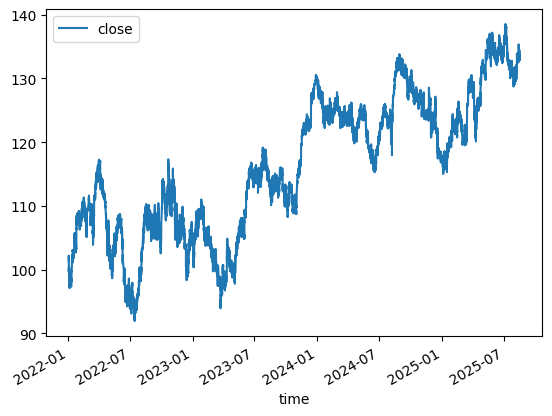

In [52]:
ts.data.plot()

## Use the data

In [5]:
## Use the data and build on unix enviroment
import numpy as np
import pandas as pd
import torch
from finpie.analytics.llm import LLMForecaster, MarketTokenizer
from finpie.data.timeseries import TimeSeries

In [6]:
ret = ts.returns(intraday_only=True)

In [ ]:
# 2. Initialize the forecaster
forecaster = LLMForecaster(vocab_size=128)

LLMForecaster initialized with device: cuda:0
GPU: NVIDIA GeForce RTX 3090
GPU Memory: 25.8 GB
CUDA Version: 12.6


In [8]:
# 3. Prepare the dataset
forecaster.build_dataset(ret.data['close'])

In [9]:
ret.data['close']

time
2022-01-03 10:09:00    0.001084
2022-01-03 10:10:00    0.001378
2022-01-03 10:11:00    0.000885
2022-01-03 10:12:00   -0.000688
2022-01-03 10:13:00    0.001573
                         ...   
2025-08-15 13:09:00    0.000150
2025-08-15 13:10:00   -0.000075
2025-08-15 13:11:00    0.000075
2025-08-15 13:12:00    0.000225
2025-08-15 13:13:00   -0.000225
Name: close, Length: 395561, dtype: float64

In [10]:
# 4. Build and train the model
forecaster.build_model()
forecaster.train(epochs = 5, track_metrics=True)

Epoch 1/5, Loss: 0.6232
Epoch 2/5, Loss: 0.5805
   Progress: 6.9% improvement from initial loss
Epoch 3/5, Loss: 0.5795
   Progress: 7.0% improvement from initial loss
Epoch 4/5, Loss: 0.5791
   Progress: 7.1% improvement from initial loss
Epoch 5/5, Loss: 0.5788
   INFO: Loss plateau detected (variance < 0.001)
   Progress: 7.1% improvement from initial loss


In [13]:
forecaster.save_model("models/bova11_llm_v1")
forecaster.export_model_info("models/bova11_llm_v1_info.txt")

Model saved successfully to: models/bova11_llm_v1.pth
   Model config: vocab_size=64, emb_dim=64
   Training history: 5 epochs
   Final loss: 0.5788
Model information saved to: models/bova11_llm_v1_info.txt


'FINANCIAL LLM MODEL INFORMATION\n==================================================\n\nModel Architecture:\n   Vocabulary Size: 64\n   Embedding Dimension: 64\n   Sequence Length: 60\n   Batch Size: 256\n   Learning Rate: 0.0003\n\nModel Parameters:\n   Total Parameters: 636,096\n   Trainable Parameters: 636,096\n\nTraining Information:\n   Epochs Trained: 5\n   Initial Loss: 0.6232\n   Final Loss: 0.5788\n   Best Loss: 0.5788\n   Improvement: 7.1%\n   Convergence Status: converged\n\nPerformance Assessment:\n   Random Baseline: 4.1589\n   Improvement over Random: 86.1%\n   Status: EXCELLENT\n\nHardware Information:\n   Device: cuda:0\n   GPU: NVIDIA GeForce RTX 3090\n   CUDA Version: 12.6'

In [15]:
forecaster = LLMForecaster.from_saved_model("models/bova11_llm_v1")

Loading model from: models/bova11_llm_v1.pth
Optimizer state restored (can resume training)
Model loaded successfully!
   Architecture: vocab_size=64, emb_dim=64
   Training history: 5 epochs
   Final training loss: 0.5788
   Convergence status: converged


In [22]:
# 5. Generate predictions
# Create a prompt from recent market data
recent_data = ret.data['close'].iloc[-60:]
print(recent_data.tail())
predicted = forecaster.fit(pd.Series(recent_data), steps=5)
print(predicted)

time
2025-08-15 13:09:00    0.000150
2025-08-15 13:10:00   -0.000075
2025-08-15 13:11:00    0.000075
2025-08-15 13:12:00    0.000225
2025-08-15 13:13:00   -0.000225
Name: close, dtype: float64
2025-08-16 13:13:00    0.001608
2025-08-17 13:13:00    0.001608
2025-08-18 13:13:00    0.004172
2025-08-19 13:13:00    0.001608
2025-08-20 13:13:00    0.001608
Freq: D, dtype: float64



COMPREHENSIVE TRAINING ANALYSIS
Loss Metrics:
   Initial -> Final: 0.6232 -> 0.5788
   Improvement: 7.1%
   Stability (CV): 0.0297

Gradient Metrics:
   Mean norm: 0.105643
   Max norm: 10.293059

Performance Assessment:
   Random baseline: 4.1589
   Good target: 1.2477
   Your model: 0.5788
   EXCELLENT: Reached good performance target!

Recommendations:
   - Consider training for more epochs or increasing learning rate
   - Large gradients - consider gradient clipping or lower learning rate


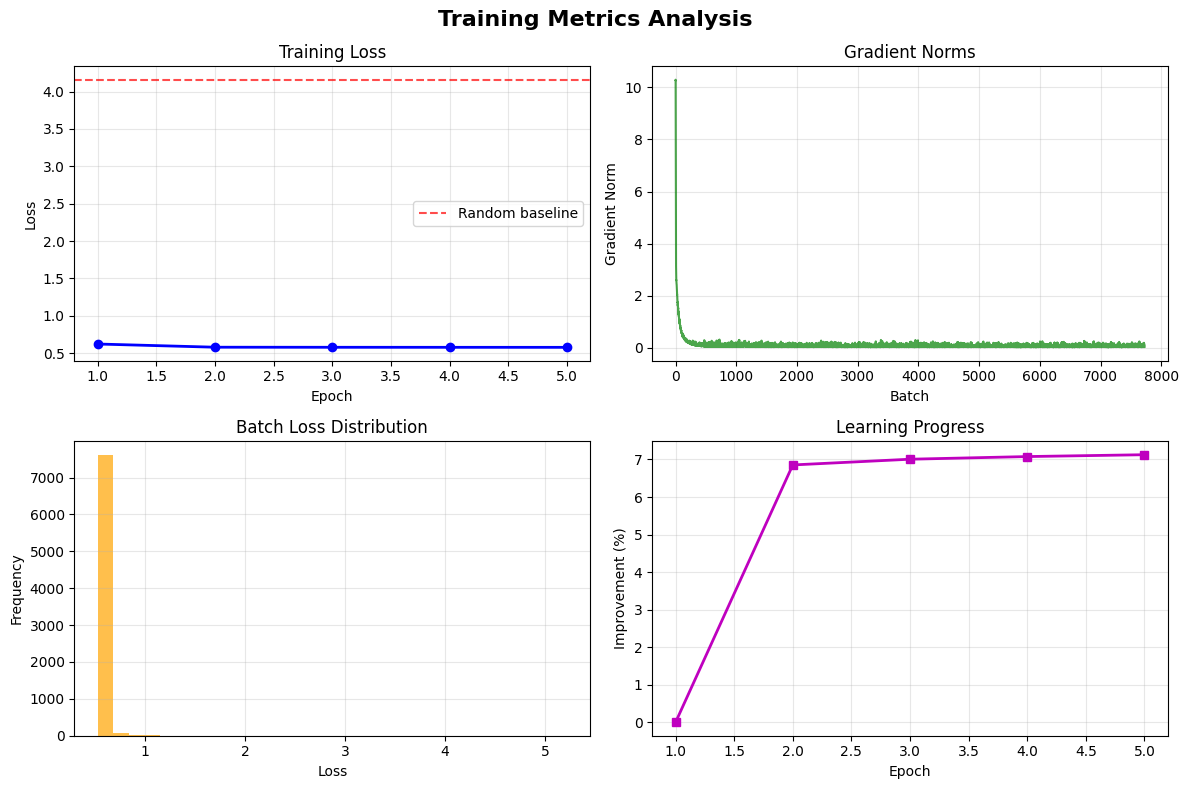

In [17]:
analysis = forecaster.analyze_training_metrics()
summary = forecaster.get_training_summary()
forecaster.plot_training_metrics()

In [38]:
lookback = 60
prediction_window = 10
threshold = 0

In [ ]:
backtest_results = []

In [ ]:
for i in range(len(ret.data)):
    if i < lookback:
        continue
    if i > len(ret.data) - prediction_window:
        break
    if i % 100 == 0:
        print(f"Processing {i} of {len(ret.data)}")
    recent_data = ret.data['close'].iloc[i-lookback:i]
    prompt = pd.Series(recent_data)
    forecaster.fit(prompt, steps=prediction_window)
    prediction = forecaster.fit(prompt, steps=prediction_window)
    cumulative_prediction = np.prod((prediction + 1).values) - 1
    if abs(cumulative_prediction) >= threshold:
        realized = np.prod((ret.data['close'].iloc[i+1:i+prediction_window+1] + 1).values) - 1
        backtest_results.append({
            'timestamp': ret.data.index[i],
            'prediction': cumulative_prediction,
            'realized': realized
        })


Processing 100 of 395561
Processing 200 of 395561
Processing 300 of 395561
Processing 400 of 395561
Processing 500 of 395561
Processing 600 of 395561
Processing 700 of 395561
Processing 800 of 395561
Processing 900 of 395561
Processing 1000 of 395561
Processing 1100 of 395561
Processing 1200 of 395561
Processing 1300 of 395561
Processing 1400 of 395561
Processing 1500 of 395561
Processing 1600 of 395561
Processing 1700 of 395561
Processing 1800 of 395561
Processing 1900 of 395561
Processing 2000 of 395561
Processing 2100 of 395561
Processing 2200 of 395561
Processing 2300 of 395561
Processing 2400 of 395561
Processing 2500 of 395561
Processing 2600 of 395561
Processing 2700 of 395561
Processing 2800 of 395561
Processing 2900 of 395561
Processing 3000 of 395561
Processing 3100 of 395561
Processing 3200 of 395561
Processing 3300 of 395561
Processing 3400 of 395561
Processing 3500 of 395561
Processing 3600 of 395561
Processing 3700 of 395561
Processing 3800 of 395561
Processing 3900 of 39

KeyboardInterrupt: 

In [43]:
df = pd.DataFrame(backtest_results)

In [49]:
df[['prediction', 'realized']].mean()

prediction    0.012954
realized     -0.000012
dtype: float64

In [62]:
# Try different vocab sizes and measure bias
for vocab_size in [32, 48, 64, 96, 128, 256]:
    tokens, bins = forecaster.tokenizer.series_to_tokens(ret.data['close'], vocab_size)
    reconstructed = forecaster.tokenizer.tokens_to_values(tokens, bins)
    bias = reconstructed.mean() - ret.data['close'].mean()
    print(f"Vocab {vocab_size}: bias = {bias:.8f}")

Vocab 32: bias = 0.00288396
Vocab 48: bias = 0.00191556
Vocab 64: bias = 0.00140015
Vocab 96: bias = 0.00089802
Vocab 128: bias = 0.00060424
Vocab 256: bias = 0.00031061
